#Image Classification using CNN Architectures

## Question 1: What is a Convolutional Neural Network (CNN)?

A Convolutional Neural Network (CNN) is a type of deep learning model specifically designed for processing image data. It uses convolutional layers to automatically detect important features such as edges, textures, and shapes.

### Differences from Fully Connected Neural Networks:
- CNN uses convolution and pooling layers, while traditional networks use only dense layers.
- CNN has fewer parameters due to weight sharing.
- CNN preserves spatial relationships in images.
- CNN performs significantly better on image-related tasks.

## Question 2: LeNet-5 Architecture

LeNet-5 is one of the earliest CNN architectures proposed by Yann LeCun in 1998.

### Architecture:
- Input: 32x32 grayscale image
- C1: Convolution layer (6 filters)
- S2: Average Pooling
- C3: Convolution layer (16 filters)
- S4: Average Pooling
- C5: Fully connected layer
- Output: Classification layer

### Importance:
- Introduced convolution and pooling operations
- Used for handwritten digit recognition
- Foundation for modern CNN architectures

Reference:
LeCun et al., "Gradient-Based Learning Applied to Document Recognition", 1998

## Question 3: AlexNet vs VGGNet

### Comparison:

- AlexNet (2012):
  - 8 layers
  - Uses large kernels (11x11)
  - Introduced ReLU and Dropout
  - Around 60 million parameters

- VGGNet (2014):
  - 16 or 19 layers
  - Uses small kernels (3x3)
  - Much deeper network
  - Around 138 million parameters

### Summary:
AlexNet introduced key innovations, while VGGNet improved accuracy with deeper architecture but increased computational cost.

## Question 4: Transfer Learning

Transfer learning is a technique where a pre-trained model is reused for a new task.

### Advantages:
- Reduces training time
- Works well with small datasets
- Improves model performance

Example: Using VGG16 trained on ImageNet for medical image classification.

## Question 5: Residual Connections in ResNet

Residual connections allow the input of a layer to be added directly to its output.

Formula:
Output = Input + F(Input)

### Benefits:
- Solves vanishing gradient problem
- Allows training of very deep networks
- Improves accuracy and convergence

# Question 6: LeNet-5 Implementation on MNIST

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
import time

# Load dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Preprocess
x_train, x_test = x_train/255.0, x_test/255.0
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

# Model
model = models.Sequential([
    layers.Conv2D(6, (5,5), activation='relu', input_shape=(28,28,1)),
    layers.AveragePooling2D(pool_size=(2,2)),
    layers.Conv2D(16, (5,5), activation='relu'),
    layers.AveragePooling2D(pool_size=(2,2)),
    layers.Flatten(),
    layers.Dense(120, activation='relu'),
    layers.Dense(84, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

start = time.time()
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))
end = time.time()

print("Training Time:", end-start)

loss, acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", acc)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.9263 - loss: 0.2372 - val_accuracy: 0.9700 - val_loss: 0.0899
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9739 - loss: 0.0842 - val_accuracy: 0.9809 - val_loss: 0.0613
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9815 - loss: 0.0595 - val_accuracy: 0.9815 - val_loss: 0.0574
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.9857 - loss: 0.0456 - val_accuracy: 0.9809 - val_loss: 0.0579
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - accuracy: 0.9882 - loss: 0.0375 - val_accuracy: 0.9851 - val_loss: 0.0477
Training Time: 151.52162194252014
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9851 - loss: 0.0477
Test Accuracy: 0.9850999712944031


# Question 7: Transfer Learning using VGG16

In [10]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,927,370 (68.39 MB)

 Trainable params: 3,212,682 (12.26 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

# Question 8: Visualizing Filters

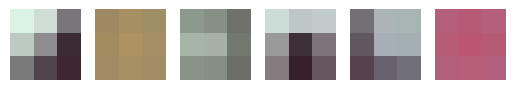

In [11]:
import matplotlib.pyplot as plt

# Access the first convolutional layer within the VGG16 base model (model.layers[0])
filters, biases = model.layers[0].layers[1].get_weights()

f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

# Assuming the first layer has at least 6 filters to visualize
for i in range(6):
    plt.subplot(1,6,i+1)
    plt.imshow(filters[:,:,:,i])
    plt.axis('off')

plt.show()

# Question 9: CIFAR-10 Training


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 60s 37ms/step - accuracy: 0.4553 - loss: 1.5103 - val_accuracy: 0.5604 - val_loss: 1.2802
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 38ms/step - accuracy: 0.6018 - loss: 1.1377 - val_accuracy: 0.6312 - val_loss: 1.0702
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 37ms/step - accuracy: 0.6470 - loss: 1.0108 - val_accuracy: 0.6620 - val_loss: 0.9742
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 38ms/step - accuracy: 0.6758 - loss: 0.9293 - val_accuracy: 0.6690 - val_loss: 0.9617
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 36ms/step - accuracy: 0.6970 - loss: 0.8686 - val_accuracy: 0.6875 - val_loss: 0.9135


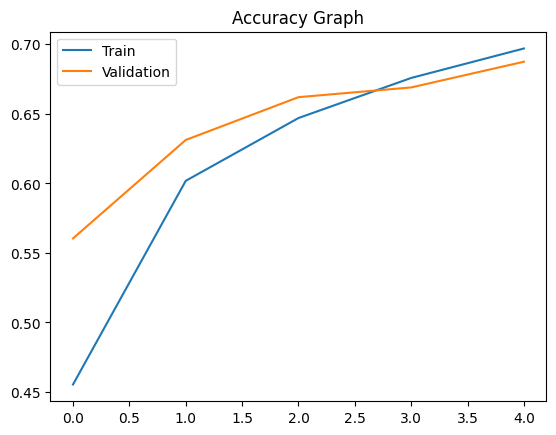

In [12]:
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train, x_test = x_train/255.0, x_test/255.0

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(10,activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title("Accuracy Graph")
plt.show()

## Question 10: Healthcare Image Classification

### Approach:
Use Transfer Learning with ResNet or Inception.

### Reasons:
- Works well with limited data
- Pre-trained on large datasets
- High accuracy

### Steps:
1. Load pre-trained ResNet50
2. Replace final layer with 3 classes
3. Fine-tune last layers

### Deployment Strategy:
- Train and save model (.h5)
- Build API using Flask
- Deploy on cloud (AWS/GCP)
- Use Docker for scalability

In [13]:
# Model Example

from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])